# 03 — PCA analysis (cell-level + well-level)


## 0. Setup

Same load + filter as notebook 02.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "df_clean_wide.csv")
mapping = pd.DataFrame({
    "Metadata_JCP2022": ["JCP2022_033924", "JCP2022_095995", "JCP2022_001418", "JCP2022_094347", "JCP2022_051785"],
    "drug_name":        ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"],
    "category":         ["control", "senescence_inducer", "senescence_inducer", "senescence_inducer", "seno_modulator"],
})
df = df.merge(mapping, on="Metadata_JCP2022", how="left")
df = df[
    (df["Cells_AreaShape_FormFactor"] <= 1)   & (df["Nuclei_AreaShape_FormFactor"] <= 1) &
    (df["Cells_AreaShape_EulerNumber"] == 1)  & (df["Nuclei_AreaShape_EulerNumber"] == 1) &
    (df["NC_Ratio"] <= 1)                     & (df["NC_Ratio_Radius"] <= 1)
].copy()

DRUG_ORDER  = ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"]
DRUG_COLORS = {"DMSO": "#666666", "hydroxyurea": "#D4A017", "palbociclib": "#FF7F0E",
               "etoposide": "#D81B82", "resveratrol": "#D62728"}
sns.set_theme(style="whitegrid")

# The 16 morphology features + 2 ratios. We deliberately exclude:
#   - ImageNumber (an ID, not a measurement)
#   - Count_* columns (image-level metadata)
#   - EulerNumber columns (constant after filter — adds no information)
PCA_FEATURES = [
    "Cells_AreaShape_BoundingBoxArea",  "Cells_AreaShape_Compactness",
    "Cells_AreaShape_Eccentricity",     "Cells_AreaShape_FormFactor",
    "Cells_AreaShape_MeanRadius",       "Cells_AreaShape_Perimeter",
    "Cells_AreaShape_Solidity",
    "Nuclei_AreaShape_BoundingBoxArea", "Nuclei_AreaShape_Compactness",
    "Nuclei_AreaShape_Eccentricity",    "Nuclei_AreaShape_FormFactor",
    "Nuclei_AreaShape_MeanRadius",      "Nuclei_AreaShape_Perimeter",
    "Nuclei_AreaShape_Solidity",
    "NC_Ratio",                         "NC_Ratio_Radius",
]
print(f"Filtered cells: {len(df):,}")
print(f"Features for PCA: {len(PCA_FEATURES)}")


Filtered cells: 102,430
Features for PCA: 16


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pull out the feature matrix as a NumPy array. shape: (n_cells, n_features)
X_cell = df[PCA_FEATURES].values

scaler = StandardScaler()
X_cell_scaled = scaler.fit_transform(X_cell)

print("Feature matrix shape:", X_cell.shape)
print("Mean of scaled features (should be ~0):", X_cell_scaled.mean(axis=0).round(3)[:5], "...")
print("Std  of scaled features (should be ~1):", X_cell_scaled.std(axis=0).round(3)[:5], "...")


Feature matrix shape: (102430, 16)
Mean of scaled features (should be ~0): [-0. -0.  0.  0. -0.] ...
Std  of scaled features (should be ~1): [1. 1. 1. 1. 1.] ...


## 2. Cell-level PCA

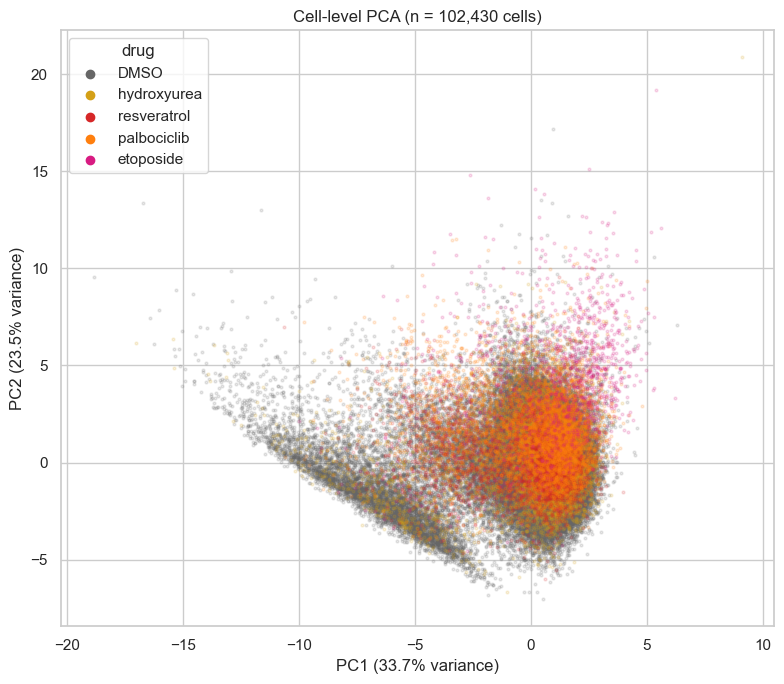

In [3]:
pca_cell = PCA(n_components=len(PCA_FEATURES))
scores_cell = pca_cell.fit_transform(X_cell_scaled)   # shape: (n_cells, n_components)

# Wrap into a DataFrame so we can plot easily.
cell_pc_df = pd.DataFrame(scores_cell[:, :3], columns=["PC1", "PC2", "PC3"])
cell_pc_df["drug_name"] = df["drug_name"].values
cell_pc_df["Metadata_Plate"] = df["Metadata_Plate"].values

# Plot PC1 vs PC2, drugs in z-order so DMSO is at the back.
fig, ax = plt.subplots(figsize=(8, 7))
plot_order = ["DMSO", "hydroxyurea", "resveratrol", "palbociclib", "etoposide"]
for drug in plot_order:
    sub = cell_pc_df[cell_pc_df["drug_name"] == drug]
    ax.scatter(sub["PC1"], sub["PC2"], s=4, alpha=0.15, color=DRUG_COLORS[drug], label=drug)

ax.set_xlabel(f"PC1 ({pca_cell.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_cell.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Cell-level PCA (n = {:,} cells)".format(len(df)))
# Make legend dots opaque so they're visible.
leg = ax.legend(title="drug", loc="best", markerscale=3)
for h in leg.legend_handles:
    h.set_alpha(1.0)

plt.tight_layout()
fig.savefig(FIGURES / "pca_cell_level.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Variance explained per principal component


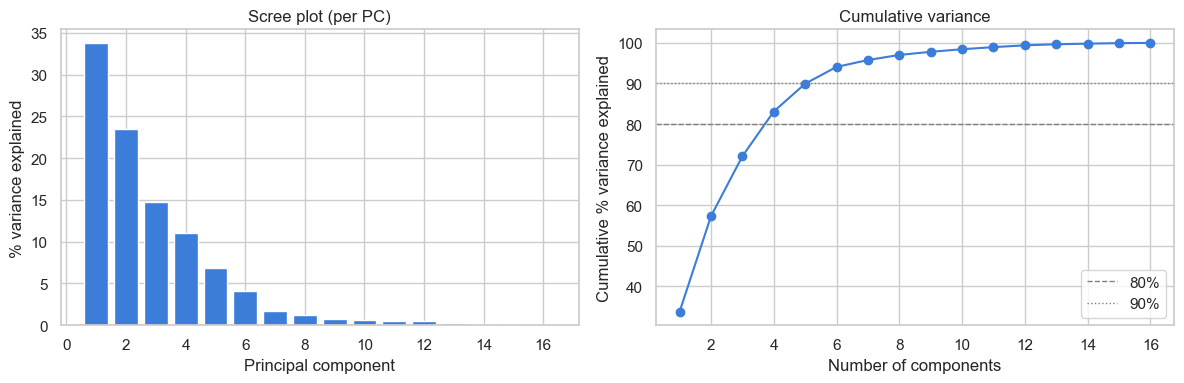

PC1:  33.7%  (cumulative:  33.7%)
PC2:  23.5%  (cumulative:  57.3%)
PC3:  14.8%  (cumulative:  72.0%)
PC4:  11.0%  (cumulative:  83.1%)
PC5:   6.9%  (cumulative:  89.9%)
PC6:   4.1%  (cumulative:  94.1%)


In [4]:
var_ratio = pca_cell.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(var_ratio)+1), var_ratio*100, color="#3B7DD8")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("% variance explained")
axes[0].set_title("Scree plot (per PC)")

axes[1].plot(range(1, len(cum_var)+1), cum_var*100, marker="o", color="#3B7DD8")
axes[1].axhline(80, color="grey", linestyle="--", linewidth=1, label="80%")
axes[1].axhline(90, color="grey", linestyle=":", linewidth=1, label="90%")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative % variance explained")
axes[1].set_title("Cumulative variance")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES / "pca_scree.png", dpi=200, bbox_inches="tight")
plt.show()

# Print the numbers
for i in range(min(6, len(var_ratio))):
    print(f"PC{i+1}: {var_ratio[i]*100:5.1f}%  (cumulative: {cum_var[i]*100:5.1f}%)")


## 4. Loadings


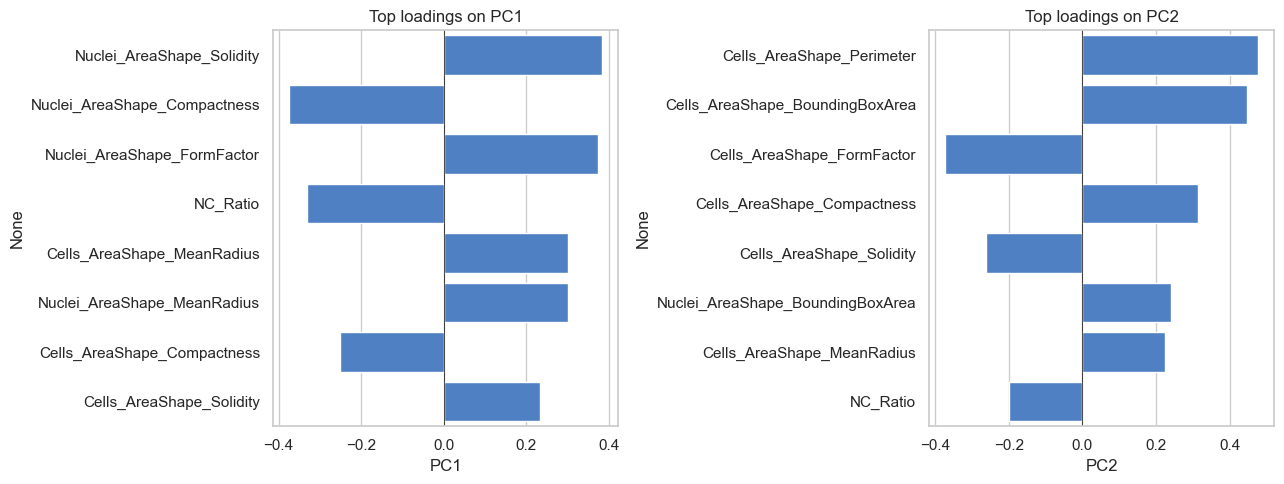

Loadings table saved to /Users/zhangyuxiang/Desktop/cell-aging-analysis/outputs/tables/pca_loadings.csv


In [5]:

loadings = pd.DataFrame(
    pca_cell.components_.T,
    index=PCA_FEATURES,
    columns=[f"PC{i+1}" for i in range(pca_cell.components_.shape[0])],
)

# Show the strongest loadings on PC1 and PC2
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(8).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(8).index

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=loadings.loc[top_pc1, "PC1"], y=top_pc1, ax=axes[0], color="#3B7DD8")
axes[0].set_title("Top loadings on PC1")
axes[0].axvline(0, color="black", linewidth=0.5)

sns.barplot(x=loadings.loc[top_pc2, "PC2"], y=top_pc2, ax=axes[1], color="#3B7DD8")
axes[1].set_title("Top loadings on PC2")
axes[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGURES / "pca_loadings.png", dpi=200, bbox_inches="tight")
plt.show()

# Save full loadings table
loadings.round(3).to_csv(TABLES / "pca_loadings.csv")
print(f"Loadings table saved to {TABLES / 'pca_loadings.csv'}")


## 5. Well-level PCA
Since cells inside the same well aren't independent observations. I just made a test to look at it. Here I aggregate to wells first, standarize it, and then PCA on the well profiles. The result is more honest and easier to interpret: 50 dots instead of 100,000 dots, each dot being one experimental replicate.

However, this may not help for our analysis, because clearly there are difference between different experimental condition. So this just as a reference.

In [6]:
# Group cells by (plate, well) and take the median of every feature.
well_df = (df
    .groupby(["Metadata_Plate", "Metadata_Well"], as_index=False)
    .agg(
        # Take the median of each feature
        **{f: (f, "median") for f in PCA_FEATURES},
        # Carry over drug_name (constant per well) — use 'first' aggregator
        drug_name=("drug_name", "first"),
        n_cells=("drug_name", "size"),
    )
)

print(f"Number of wells: {len(well_df)}")
print("Wells per drug:")
print(well_df["drug_name"].value_counts().to_string())


Number of wells: 49
Wells per drug:
drug_name
DMSO           38
palbociclib     4
hydroxyurea     3
etoposide       2
resveratrol     2


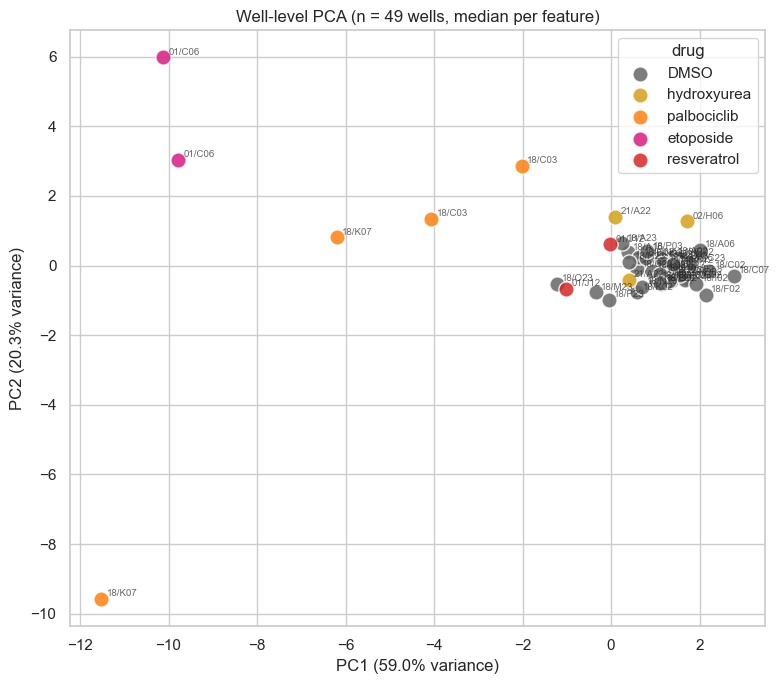

In [7]:
# Standardize and PCA at the well level.
X_well = well_df[PCA_FEATURES].values
X_well_scaled = StandardScaler().fit_transform(X_well)

pca_well = PCA(n_components=min(len(well_df), len(PCA_FEATURES)))
scores_well = pca_well.fit_transform(X_well_scaled)
well_df["PC1"] = scores_well[:, 0]
well_df["PC2"] = scores_well[:, 1]

fig, ax = plt.subplots(figsize=(8, 7))
for drug in DRUG_ORDER:
    sub = well_df[well_df["drug_name"] == drug]
    ax.scatter(sub["PC1"], sub["PC2"], s=120, alpha=0.85, color=DRUG_COLORS[drug],
               edgecolor="white", linewidth=1.0, label=drug)
    # Label each dot with the well ID for traceability
    for _, row in sub.iterrows():
        ax.annotate(f"{row['Metadata_Plate'][-2:]}/{row['Metadata_Well']}",
                    (row["PC1"], row["PC2"]), fontsize=7, alpha=0.7,
                    xytext=(4, 2), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca_well.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_well.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title(f"Well-level PCA (n = {len(well_df)} wells, median per feature)")
ax.legend(title="drug", loc="best")
plt.tight_layout()
fig.savefig(FIGURES / "pca_well_level.png", dpi=200, bbox_inches="tight")
plt.show()
